Generating the positioning the GNSS
Author: Brandon Engelbrecht

NOTE:
    We make use of the MeerKAT/meerkat_utils package found on GH and owned by Dr. Yi-Chao Li

In [16]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Python
import pickle
import sys
import time
from datetime import datetime
import pytz
import os
# Python Files
from satellite_RFI.src import check_satellite as cs
from satellite_RFI.src import beam_model as bm
from satellite_RFI.src import rewrite_tle
from satellite_RFI.src import satellite_extract
from satellite_RFI.src import tle_sat_download as tsd
# Astropy
from astropy.time import Time
import astropy.units as u
import astropy.constants as cc
# Numpy
import numpy as np
#  Matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as md


### -------------------------------------------- Satellite Position--------------------------------------------

In [3]:
# print """

# obs_time\tUser enters the date and time of observation with respect to UTC time\n\t\tformat: YYYY MM DD hh mm ss

# nd_s\t\tthe scanning timestamps (can leave empty)

# nd_s0\t\ta list of the scan in seconds should be given here,\n\t\tthis is added to the fname/obs_time and can be the\n\t\tscanning zone, in seconds or timestamp seconds

# frequency\ta list of the frequency for the observation\n\t\t(f0, f1, f2....., fn) [Units MHz]

# fs,fe\t\tThe starting and ending point of the frequency [Units MHz]\n
# \t\tIf None, will use the entire frequency band

# timestamps\tcan leave empty

# telescopeLon/Lat The longitude and latitude of the telescope position

# nd_s0_coords\ta tuple of (AZ_list, ALT_list), these should be of\n\t\tequal size and equal to the length of nd_s0
               
# data_save\tlocation to save the data

# tle_location\tlocation of the TLE satellite inforamtion for the observation

# sats_type\tthe different satellite constellations for the satellites:\n\t\tname variable should correspond to the file name xxx.txt

# tle_data_sort\tGiven the format of the TLE from the website, the data needs to be processed first.\n\t\tNone to do nothing
# """

In [6]:
katdal_info = pickle.load(open('../../Outputs/Jy_test/1631379874_katdal_info.p', 'rb'))
info = [katdal_info[i] for i in katdal_info.keys()]
katdal_info.keys()

['nd_s0', 'frequency', 'nd_s0_coords']

In [14]:
obs_time_input='2021 9 30 20 06 36'
fname = None
tle_location=None

if tle_location==None:
    tle_location=tsd.tle_download(direc_path="TLE/")
    
print ("TLE location: "+tle_location) 


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    fname=1631379874
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(fname).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date:"+str(dt))



File name to be used is: 1633032396
Path alredy exists: TLE/2021_09_30_tle/
TLE location: TLE/2021_09_30_tle/


In [15]:

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500
telescope_Lon =  (21. + 26./60. + 38.00/3600.) * u.deg #
telescope_Lat = -(30. + 42./60. + 47.41/3600.) * u.deg #
data_save='../../Outputs/Jy_test/'

 
sats_type =['gps-ops', 'glo-ops', 'galileo', 'beidou', 'irnss', 'qzs', 'sbas']   
tle_data_sort=1

"""
Rewriting the TLE data
"""
if tle_data_sort is not None: 
    print 'Extracting IRNSS and QZs'
    satellite_extract.sat_extract(folder=tle_location)
    print 'Extract complete '
    print 'Re-writing data'
    rewrite_tle.rewrite_sat_cat(file_path=tle_location)
    print 'Re-write completed'

Extracting IRNSS and QZs
Extract complete 
Re-writing data
Re-write completed


In [8]:
# print 'start @ ' + time.asctime(time.localtime(time.time())) +'...'

In [9]:
"""
Python CLASS to initialize the data
"""
tsc = cs.Telescopesite_Satellite_Catalogue(source_url=tle_location, 
                                         sats_type=sats_type, 
                                         reload=False)

tsc.obs_time= datetime.utcfromtimestamp(int(fname)+nd_s0[0]).strftime('%Y-%m-%d %H:%M:%S')
tsc.obs_time_list = (nd_s0 - nd_s0[0]) * u.second


tsc.obs_location = [telescope_Lat, telescope_Lon]


tsc.get_sate_coords()




load sat catalogue from TLE/2021_09_06_tle/ gps-ops.txt
load sat catalogue from TLE/2021_09_06_tle/ glo-ops.txt
load sat catalogue from TLE/2021_09_06_tle/ galileo.txt
load sat catalogue from TLE/2021_09_06_tle/ beidou.txt
load sat catalogue from TLE/2021_09_06_tle/ irnss.txt
load sat catalogue from TLE/2021_09_06_tle/ qzs.txt
load sat catalogue from TLE/2021_09_06_tle/ sbas.txt
Time range 2021-09-11 17:04:34.000 - 2021-09-11 19:06:44.899
Satellite      gps-ops has   16 satellites  [use   6.27 s]
Satellite      glo-ops has   14 satellites  [use   5.63 s]
Satellite      galileo has   12 satellites  [use   4.73 s]
Satellite       beidou has   25 satellites  [use   9.24 s]
Satellite        irnss has    6 satellites  [use   3.20 s]
Satellite          qzs has    0 satellites [Removing this constellation from sats_type]
Satellite         sbas has    8 satellites  [use   4.04 s]


In [10]:
"""
Satellite Pointing coordinates
"""
telescope_pointing =  np.array([[nd_s0_coords[0][i], nd_s0_coords[1][i]] for i 
                      in range(len(nd_s0_coords[0]))])

In [11]:
"""
Satellite position on the sky with respect to the telescope
"""

satellite_angle = tsc.check_angular_separation(
    pointings=telescope_pointing, max_angle=100, beam_func=None, 
    ymin=1e-10, ymax=1, axes=None)


In [12]:

# Plotting
for i in range(len(tsc.sats_type_remain)):
    print "Satellite angles for: ", tsc.sats_type_remain[i]
    satellite_angle[i] = satellite_angle[i].T

Satellite angles for:  gps-ops
Satellite angles for:  glo-ops
Satellite angles for:  galileo
Satellite angles for:  beidou
Satellite angles for:  irnss
Satellite angles for:  sbas


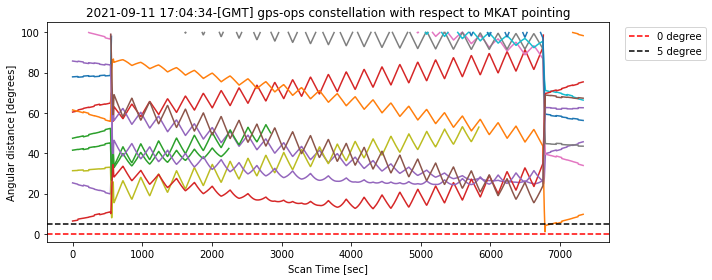

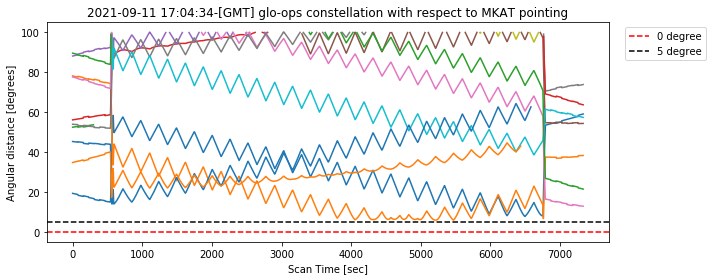

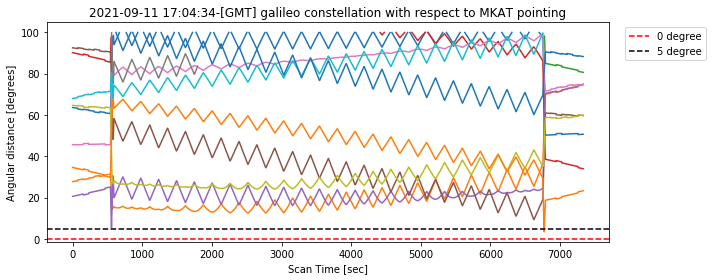

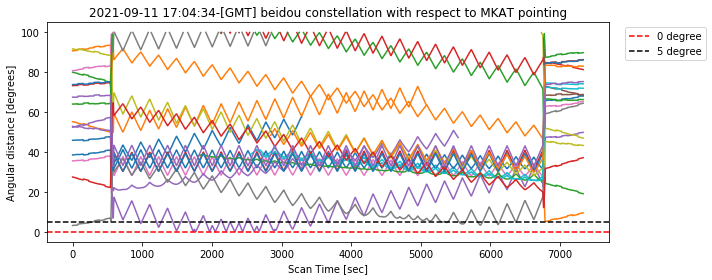

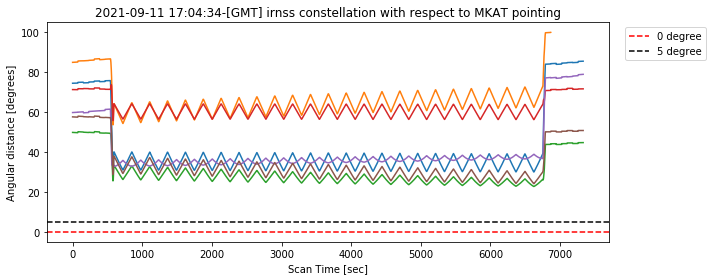

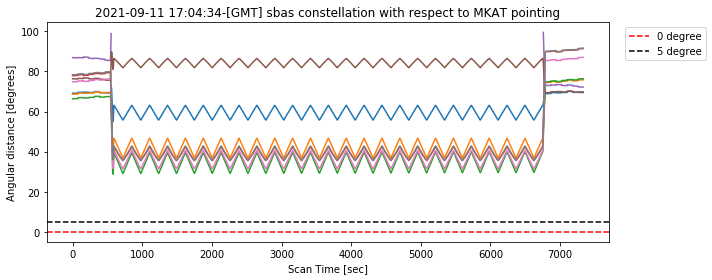

In [13]:
for i in range(len(tsc.sats_type_remain)):
    plt.figure(figsize=(10, 4))
    
    for j in satellite_angle[i]:
        plt.plot(nd_s0, j)
    plt.axhline(0, color='red', linestyle='--', label= '0 degree')
    plt.axhline(5, color='black', linestyle='--', label= '5 degree')


    plt.title(dt+'-[GMT] '+tsc.sats_type_remain[i]+' constellation with respect to MKAT pointing')
    plt.xlabel('Scan Time [sec]')
    plt.ylabel('Angular distance [degrees]')  # Make a some symbol name
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('../../Outputs/Jy_test/'+str(fname)+'_'+tsc.sats_type_remain[i]+'_satellite_distance.pdf')
    plt.show()



In [17]:
def satellite_timestream(frequency, pointing_position):
    '''
    Produces the angular seperation plots for the freqeuncy given and pointing
    Uses some global variabes like 
    Frequency - ini, end, channel'''
    
    ## Code from satellite_timestream
    freq = frequency  
#     beam_func = bm.Khans_beam_model(freq=freq)
#     beam_func = bm.Cosine_beam_model(freq=freq)       # using cosine beam model
    beam_func = bm.emss_beam_model(f=freq)              # using meerkat model beam

    stype, sname, stemperature = [], [], []

    for _sat_info in tsc.itersats_temperature(pointings=pointing_position, beam_func=beam_func, close_angle=5):
        _sat_type, _sat_names, _temperature = _sat_info
        print 'Sat. Name includes %s ...'%_sat_names[0] # includes the name of each sat
        print 'N_freq x N_time x N_sats = %d x %d x %d '%_temperature.shape
        print
        np.array(stype.append(_sat_type)), sname.append(_sat_names), stemperature.append(np.sum(_temperature[:,:,:], axis=2))

        del _temperature 
    return stype, sname, np.array(stemperature)


In [18]:
"""
Frequency and frequency channels
"""
if fs and fe is not None: 
    channel_start_idx = (np.where(frequency > fs)[0][0])
    channel_end_idx = (np.where(frequency > fe)[0][0]) 

elif fs is None and fe is not None:
    channel_start_idx = frequency[0]
    channel_end_idx = (np.where(frequency > fe)[0][0]) 

elif fs is not None and fe is None:
    channel_start_idx = (np.where(frequency > fs)[0][0])
    channel_end_idx = frequency[-1]

frequency_band = frequency[channel_start_idx-1:channel_end_idx+1]

print 'Frequency band:', frequency_band

Frequency band: [1000.  1000.2 1000.4 ... 1499.7 1499.9 1500.1]


In [19]:
sat_type, sat_names, stemperature = satellite_timestream(
    frequency=frequency_band, pointing_position=telescope_pointing)

Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 3647 x 16 

Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 3647 x 14 

Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 3647 x 12 

Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 3647 x 25 

Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 3647 x 6 

Sat. Name includes  ...
N_freq x N_time x N_sats = 2394 x 3647 x 8 




In [20]:
sat_names

[array([u'', u'', u'', u'', u'', u'', u'', u'', u'', u'', u'',
        u'GPS-BIIF-6--(PRN-06)----', u'', u'', u'', u''], dtype='<U24'),
 array([u'', u'COSMOS-2544-(759)-------', u'', u'', u'', u'', u'', u'',
        u'', u'', u'', u'', u'', u''], dtype='<U24'),
 array([u'', u'', u'', u'', u'', u'', u'', u'', u'', u'', u'',
        u'GSAT0220-(PRN-E13)------'], dtype='<U24'),
 array([u'', u'', u'', u'', u'BEIDOU-3-M1-(C19)-------', u'', u'', u'',
        u'', u'', u'', u'', u'', u'', u'', u'', u'',
        u'BEIDOU-3-M15-(C34)------', u'', u'', u'', u'', u'', u'', u''],
       dtype='<U24'),
 array([u'', u'', u'', u'', u'', u''], dtype='<U24'),
 array([u'', u'', u'', u'', u'', u'', u'', u''], dtype='<U24')]

In [21]:
# w = 10
# h = 10
# fig = plt.figure(figsize=(22, 16))
# columns = 7
# rows = 7
# for i in range(1, columns*rows +1):
#     try:
#         img = stemperature[:,:,i-1]
#     except IndexError:
#         continue
#     fig.add_subplot(rows, columns, i)
#     plt.title('Satellite: '+str(i-1))
#     a_img = plt.imshow(img, aspect='auto', extent=[nd_s0[0], nd_s0[-1], frequency_band[-1], frequency_band[0]])
#     plt.ylabel('Frequency [MHz]')
#     plt.xlabel('Time [sec]')
#     plt.colorbar(a_img)

# plt.tight_layout()
# # plt.savefig('../../../Plots/'+fname+'_emss_beam_gps_all2.png')
# plt.show()

In [ ]:
# Created a dictionary and pickled values for the GPS, Galileo, GLO and Bei

sat_pos = {
    'sat_name': sat_type,
    'angular': stemperature 
}

pickle.dump(sat_pos, open(data_save+str(fname)+"_satellite_angular_position_emss_beam_r.p", "wb"))

In [ ]:
print 'end @ ' + time.asctime(time.localtime(time.time())) +'#'

of### -----------------------------------------------------END-------------------------------------------------------